# Numerical Integration and Differentiation

examples

In [48]:
import numpy as np
from fractions import Fraction
from functools import reduce, lru_cache

from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)  # 抑制科学计数法，小数位6位

def sign(x):
    s = np.sign(x)
    return s if s else 1

In [49]:
def monomial_coef(nodes, b):
    A = np.vander(nodes, increasing=True)
    return la.solve(A, b)


def monomial_bases(nodes):
    return [Polynomial([0] * n + [1]) for n in range(len(nodes))]


def lagrange_bases(nodes):
    nodes = np.array(nodes, dtype=float)
    n = len(nodes)
    lx = [reduce(Polynomial.__mul__, [Polynomial([-a, 1])for a in nodes[np.arange(n) != i]]) for i in range(n)]
    wx = [1 / (nodes[i] - nodes[np.arange(n) != i]).prod() for i in range(n)]
    return [l * w for l, w in zip(lx, wx)]


def newton_bases(nodes):
    nodes = np.array(nodes, dtype=float)
    n = len(nodes)
    return [Polynomial([1])] + [reduce(Polynomial.__mul__, [Polynomial([-a, 1]) for a in nodes[:i+1]]) for i in range(n-1)]


def newton_coef_axb(nodes, b):
    nodes = np.array(nodes, dtype=float)
    ps = newton_bases(nodes)
    A = np.array([p(nodes) for p in ps]).T
    # print(np.linalg.cond(A))
    return la.solve(A, b)


def newton_incr(q, p, x, y):
    return (y - q(x)) / p(x)


def newton_coef_incr(nodes, b):
    ps = newton_bases(nodes)
    qs = [Polynomial([b[0]])]
    xs = [b[0]]
    for i in range(1, len(nodes)):
        xs.append(newton_incr(qs[-1], ps[i], nodes[i], b[i]))
        qs.append(qs[-1] + xs[-1] * ps[i])
    return np.array(xs)


def newton_coef_recur(nodes, b):

    @lru_cache
    def divided_difference(i, j):
        if i == j:
            return b[i]
        else:
            return (divided_difference(i+1, j) - divided_difference(i, j-1)) / (nodes[j] - nodes[i])
        
    return np.array([divided_difference(0, i) for i in range(len(nodes))])


def monomial_horner(coef, x):
    s = np.zeros_like(x) if isinstance(x, np.ndarray) else 0
    for a in coef[::-1][:-1]:
        s = (s + a) * x
    s += coef[0]
    return s


def newton_horner(coef, x, nodes):
    coef, nodes = coef[::-1], nodes[::-1]
    s = np.zeros_like(x) if isinstance(x, np.ndarray) else 0
    for a, t in zip(coef, nodes[1:]):
        s = (s + a) * (x - t)
    s += coef[-1]
    return s

In [50]:
def open_newton_cotes(a, b, n):
    return np.linspace(a, b, n+2)[1:-1]


def closed_newton_cotes(a, b, n):
    return np.linspace(a, b, n)


def midpoint(f, a, b):
    return (b - a) * f((a + b) / 2)


def trapezoid(f, a, b):
    return .5 * (b - a) * (f(a) + f(b))


def simpson(f, a, b):
    return 1 / 6 * (b - a) * (f(a) + 4 * f((a + b) / 2) + f(b))

0.7788007830714049
0.6839397205857212
0.7471804289095104
<class 'numpy.polynomial.polynomial.Polynomial'>


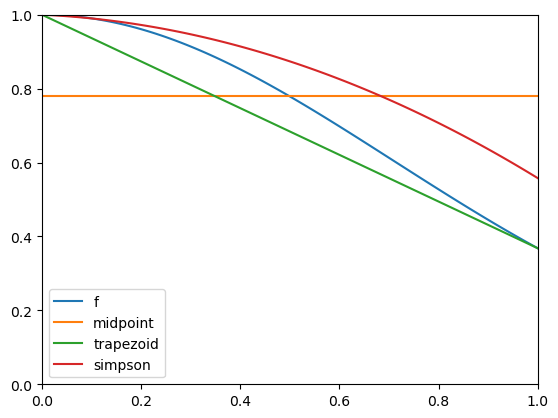

In [51]:
# 8.2
def f(x):
    return np.exp(- x ** 2)

print(midpoint(f, 0, 1))
print(trapezoid(f, 0, 1))
print(simpson(f, 0, 1))

pm = sum(w * p for w, p in zip(monomial_coef([.5], [f(.5)]), monomial_bases([.5])))
print(type(pm))
pt = sum(w * p for w, p in zip([f(0), f(1)], lagrange_bases([0, 1])))
ps = sum(w * p for w, p in zip(newton_coef_incr([0, .5, 1], [f(0), f(.5), f(1)]), newton_bases([0, .5, 1])))

x = np.linspace(0, 1, 101)
plt.plot(x, f(x), label='f')
plt.plot(x, monomial_horner(pm.coef, x), label='midpoint')
plt.plot(x, pt(x), label='trapezoid')
plt.plot(x, newton_horner(ps.coef, x, [0, .5, 1]), label='simpson')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()

In [52]:
# 8.3
im = Fraction(midpoint(np.square, 0, 1))
it = Fraction(trapezoid(np.square, 0, 1))
e = (it - im) / 3
print(im, it, e)

print(im * 2 / 3 + it / 3)
print(simpson(np.square, 0, 1))

1/4 1/2 1/12
1/3
0.3333333333333333


In [53]:
# Chebyshev extrema progressive
n = 10
n_roots = special.chebyu(n).roots

cnt = 0
for x in special.chebyu(2 * n + 1).roots:
    if np.abs(n_roots - x).min() > 1e-8:
        cnt += 1
cnt

11

In [54]:
# 8.4
def f(x):
    return np.array([
        x[0] + x[1] - 2,
        x[0] * x[2] + x[1] * x[3],
        x[0] * x[2] ** 2 + x[1] * x[3] ** 2 - 2 / 3,
        x[0] * x[2] ** 3 + x[1] * x[3] ** 3,
    ])


opt.root(f, [0, 0, 1, 1])

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00 -9.343e-13 -5.618e-12  1.562e-12]
       x: [ 1.000e+00  1.000e+00  5.774e-01 -5.774e-01]
  method: hybr
    nfev: 45
    fjac: [[-8.404e-01 -4.834e-01 -1.295e-01  2.082e-01]
           [-5.406e-01  7.331e-01  1.619e-01 -3.796e-01]
           [ 3.796e-02 -1.972e-01 -6.656e-01 -7.188e-01]
           [-5.497e-03  4.359e-01 -7.170e-01  5.440e-01]]
       r: [-1.190e+00 -4.970e-01 -4.606e-01 -3.195e-01 -1.077e+00
            6.321e-01  5.133e-01 -1.194e+00  4.052e-01  1.157e+00]
     qtf: [-3.983e-10  5.801e-10 -7.274e-10 -1.185e-09]

In [55]:
# gauss legendre quadrature
from numpy.polynomial import Legendre

Legendre.basis(2).roots()

array([-0.57735,  0.57735])

In [56]:
# 8.5
def standard_gauss_quad(f, n):
    if n == 2:
        return f(- 1 / np.sqrt(3)) + f(1 / np.sqrt(3))


def gauss_quad(f, a, b, n=2):
    return (b - a) / 2 * standard_gauss_quad(lambda x: f(((b - a) * x + a + b) / 2), n=n)


def f(x):
    return np.exp(- x ** 2)


gauss_quad(f, 0, 1)

np.float64(0.7465946882828598)

In [57]:
def forward_difference(f, x, h):
    return (f(x + h) - f(x)) / h


def backward_difference(f, x, h):
    return (f(x) - f(x - h)) / h


def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / 2 / h


def richardson_extrapolation(bigf, smallf, p, q):
    return bigf + (bigf - smallf) / (1 / q ** p - 1)

In [58]:
# 8.8
p, smallh, bigh = 1, .25, .5
bigf = forward_difference(np.sin, 1, bigh)
smallf = forward_difference(np.sin, 1, smallh)
extraf = richardson_extrapolation(bigf, smallf, p, q=2)
print(bigf, smallf, extraf)

0.3120480035923159 0.4300545381907588 0.5480610727892017


In [59]:
# 8.9
p, r, q = 2, 4, 2


def composite(f, a, b, k, quad):
    xs = np.linspace(a, b, k+1)
    return quad(f, xs[:-1], xs[1:]).sum()


t00 = composite(np.sin, 0, np.pi / 2, 1, quad=trapezoid)
t10 = composite(np.sin, 0, np.pi / 2, 2, quad=trapezoid)
t20 = composite(np.sin, 0, np.pi / 2, 4, quad=trapezoid)
print(t00, t10, t20)

t11 = richardson_extrapolation(t00, t10, p, q)
t21 = richardson_extrapolation(t10, t20, p, q)
print(t11, t21)

t22 = richardson_extrapolation(t11, t21, r, q)
print(t22)

0.7853981633974483 0.9480594489685199 0.9871158009727754
1.0022798774922104 1.0001345849741938
0.9999915654729927


In [60]:
# caution f is not progressively used
def romberg(f, a, b, tol=1e-8, depth=10, verbose=False):

    @lru_cache()
    def t(i, j):
        # whether extraplating
        if not j:
            return composite(f, a, b, k=2**i, quad=trapezoid)
        else:
            return richardson_extrapolation(t(i-1, j-1), t(i, j-1), p=2*j, q=2)


    for j in range(1, depth+1):
        if np.abs(t(j, j) - t(j-1, j-1)) < tol:
            break

    if verbose:
        for i in range(j+1):
            print(' '.join([f'{float(t(i, k))}' for k in range(i+1)]))
    return np.array([t(i, i) for i in range(j+1)])


romberg(np.sin, 0, np.pi / 2, tol=1e-10, depth=2, verbose=True)

0.7853981633974483
0.9480594489685199 1.0022798774922104
0.9871158009727754 1.0001345849741938 0.9999915654729927


array([0.785398, 1.00228 , 0.999992])

exercises

In [61]:
# 8.1
def f(x):
    return x ** 3


print(integrate.quad(f, 0, 1)[0])
print(midpoint(f, 0, 1))
print(trapezoid(f, 0 , 1))
print((trapezoid(f, 0 , 1) - midpoint(f, 0, 1)) / 3)
print(trapezoid(f, 0 , 1) / 3  + midpoint(f, 0, 1) * 2 / 3)

0.25
0.125
0.5
0.125
0.25


In [62]:
# 8.2
m00 = composite(f, 0, 1, 1, quad=midpoint)
m10 = composite(f, 0, 1, 2, quad=midpoint)
m11 = richardson_extrapolation(m00, m10, 2, 2)
print(m11)

0.25


In [63]:
# 8.14
p = 1
richardson_extrapolation(-.88333, -.9091, 1, 2)

-0.9348700000000001

In [64]:
# 8.15
print(richardson_extrapolation(3, 3.1058, 2, 2))
richardson_extrapolation(3.4641, 3.2154, 2, 2)

3.1410666666666667


3.1325

computer problems

C:\Users\chuny\AppData\Local\Temp\ipykernel_9064\2856711054.py:9: RuntimeWarning: divide by zero encountered in log
  plt.plot(- np.log([1 / 2 ** exponent for exponent in range(1, 10)]), - np.log(errors), label=quad.__name__)


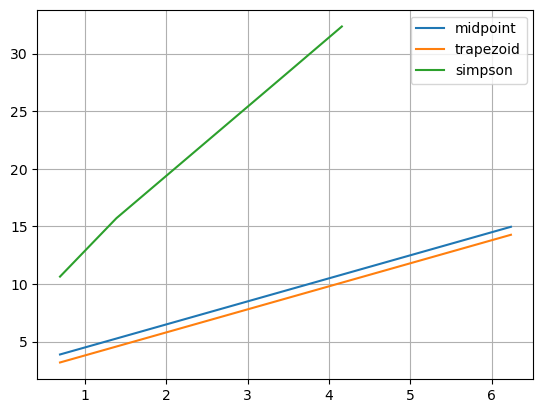

In [65]:
# 8.1
def f(x):
    return 4 / (1 + x ** 2)


for quad in [midpoint, trapezoid, simpson]:
    errors = [abs(np.pi - composite(f, 0, 1, 2 ** exponent, quad=quad)) for exponent in range(1, 10)]
    # plt.plot([1 / 2 ** exponent for exponent in range(1, 10)], errors, label=quad.__name__)
    plt.plot(- np.log([1 / 2 ** exponent for exponent in range(1, 10)]), - np.log(errors), label=quad.__name__)

# plt.axis('equal')
plt.grid(True)
plt.legend()

[3.       3.133333 3.142118 3.141586 3.141593 3.141593 3.141593]


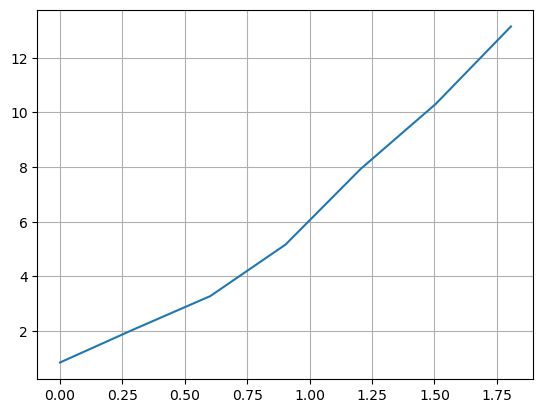

In [66]:
# (b)
vs = romberg(f, 0, 1, tol=1e-10)
print(vs)
errors = np.abs(vs - np.pi)
plt.plot(- np.log10([1 / 2 ** exponent for exponent in range(len(vs))]), - np.log10(errors))
plt.grid(True)

3.1415926535897936
3.4878684980086326e-14
21


Text(0.5, 1.0, 'Sampling points of adaptive quadrature')

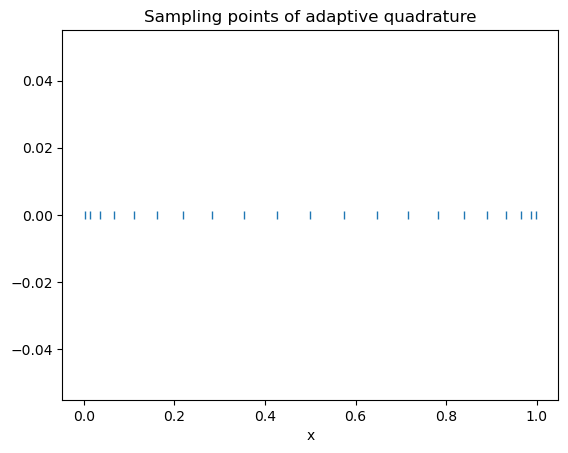

In [67]:
result, err_est = integrate.quad(f, 0, 1, epsabs=1e-10, epsrel=1e-10)
print(result)          # 3.141592653589793
print(err_est)         # ~1e-10 数量级
print(integrate.quad(f,0,1,full_output=1)[2]['neval'])  # 函数求值次数


points = []

def f_with_trace(x):
    points.append(x)
    return 4/(1+x*x)

integrate.quad(f_with_trace, 0, 1, epsabs=1e-10)

plt.plot(points, [0]*len(points), '|')
plt.xlabel('x')
plt.title('Sampling points of adaptive quadrature')

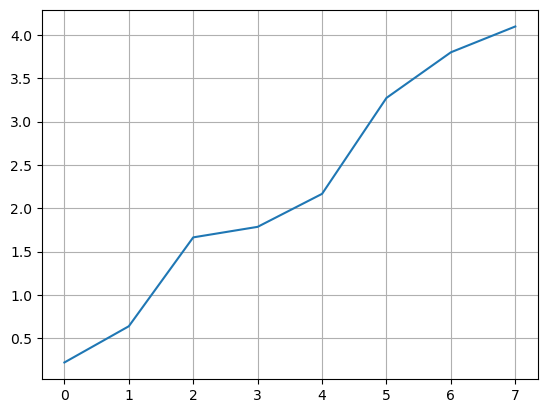

In [68]:
def monte_carlo(f, a, b, n):
    samples = a + np.random.random(n) * (b - a)
    return f(samples).mean() * (b - a)


vs = np.array([monte_carlo(f, 0, 1, 10 ** i) for i in range(8)])
errors = np.abs(vs - np.pi)
plt.plot(range(len(vs)), - np.log10(errors))
plt.grid(True)

[np.float64(3.537376553384353), np.float64(3.5663446866782427), np.float64(3.5781954202104505), np.float64(3.5829537734010235), np.float64(3.584837069781048), np.float64(3.5855739656098375), np.float64(3.5858596174950135), np.float64(3.585969491894912), np.float64(3.586011478342101)]


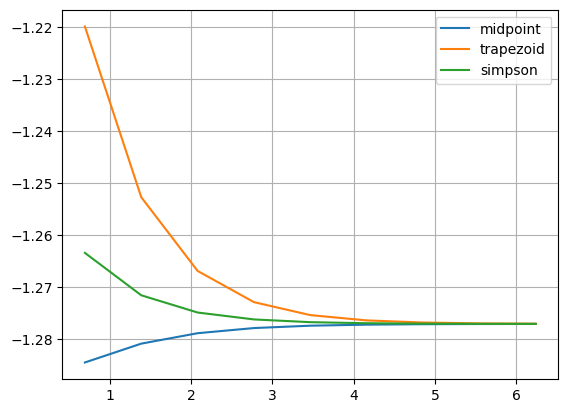

In [69]:
# 8.2
def f(x):
    y = np.zeros_like(x)
    mask = x > 0
    y[mask] =  np.sqrt(x[mask]) * np.log(x[mask])
    return y


for quad in [midpoint, trapezoid, simpson]:
    errors = [abs(np.pi - composite(f, 0, 1, 2 ** exponent, quad=quad)) for exponent in range(1, 10)]
    # plt.plot([1 / 2 ** exponent for exponent in range(1, 10)], errors, label=quad.__name__)
    plt.plot(- np.log([1 / 2 ** exponent for exponent in range(1, 10)]), - np.log(errors), label=quad.__name__)

plt.grid(True)
plt.legend()
print(errors)

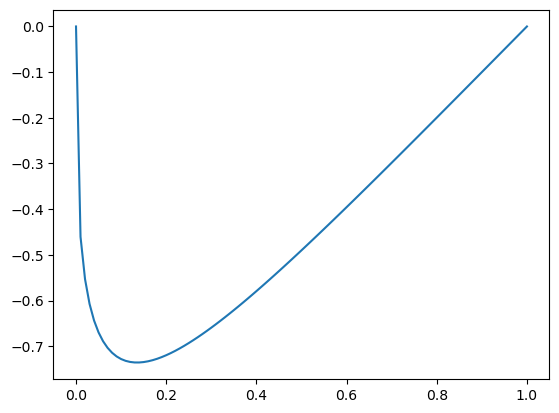

In [70]:
x = np.linspace(0, 1, 101)
plt.plot(x, f(x))

[ 0.       -0.326753 -0.400386 -0.427101 -0.437604 -0.441767 -0.443405
 -0.444044 -0.444291 -0.444386 -0.444422]
[3.141593 3.468345 3.541979 3.568693 3.579196 3.583359 3.584998 3.585637
 3.585884 3.585979 3.586015]


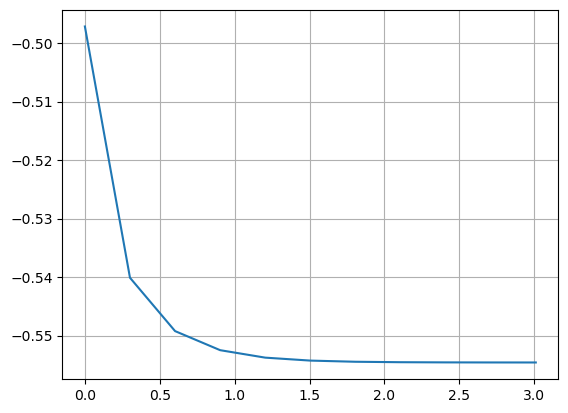

In [71]:
vs = romberg(f, 0, 1, tol=1e-10)
print(vs)
errors = np.abs(vs - np.pi)
plt.plot(- np.log10([1 / 2 ** exponent for exponent in range(len(vs))]), - np.log10(errors))
plt.grid(True)
print(errors)

[3.703619 3.50332  3.609587 3.603759 3.586622 3.584627 3.586002 3.586034]


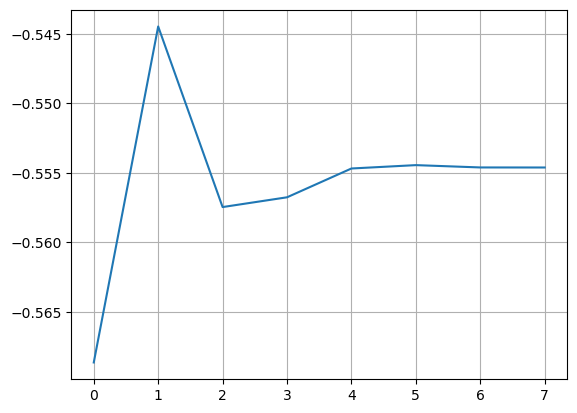

In [72]:
vs = np.array([monte_carlo(f, 0, 1, 10 ** i) for i in range(8)])
errors = np.abs(vs - np.pi)
plt.plot(range(len(vs)), - np.log10(errors))
plt.grid(True)
print(errors)

(-0.44444444444444475, 1.1102230246251565e-15) 315


Text(0.5, 1.0, 'Sampling points of adaptive quadrature')

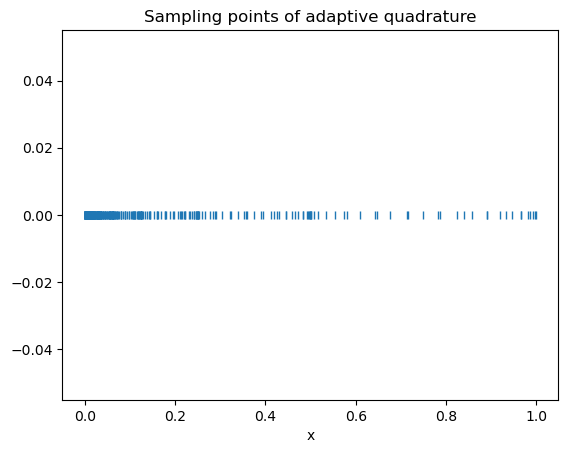

In [75]:
points = []

def f_with_trace(x):
    points.append(x)
    return 0 if not x else np.sqrt(x) * np.log(x)


out = integrate.quad(f_with_trace, 0, 1, epsabs=1e-10, full_output=1)
print(out[:2], out[2]['neval'])

plt.plot(points, [0]*len(points), '|')
plt.xlabel('x')
plt.title('Sampling points of adaptive quadrature')

1.6829419696157932
1.6829419696157972


np.float64(1.6829429056977807)

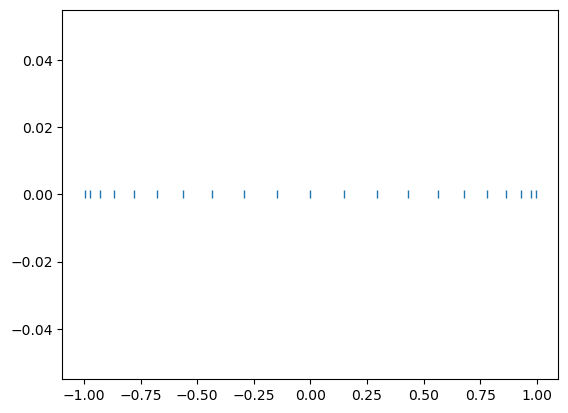

In [91]:
# 8.3
# (a)
points = []

def f(x):
    points.append(x)
    return np.cos(x)

print(integrate.quad(f, -1, 1)[0])
plt.plot(points, [0] * len(points), '|')

print(romberg(f, -1, 1)[-1])
composite(f, -1, 1, k=10, quad=simpson)

0.29422553486074704
0.2942255349063669


np.float64(0.2682626641651032)

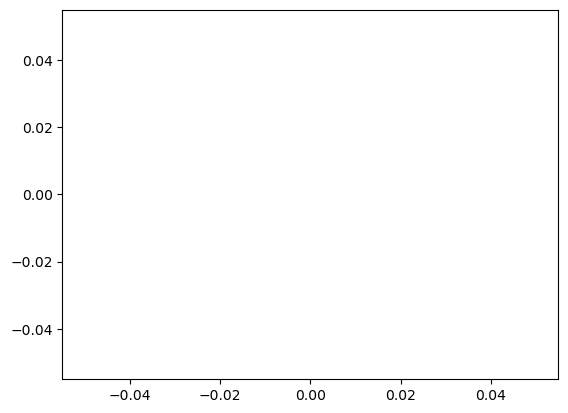

In [92]:
# (b)
points = []

def f(x):
    return 1 / (1 + 100 * x ** 2)


print(integrate.quad(f, -1, 1)[0])
plt.plot(points, [0] * len(points), '|')

print(romberg(f, -1, 1)[-1])
composite(f, -1, 1, k=10, quad=midpoint)

1.3333333333333315
1.3333214976371572


np.float64(1.299477195110013)

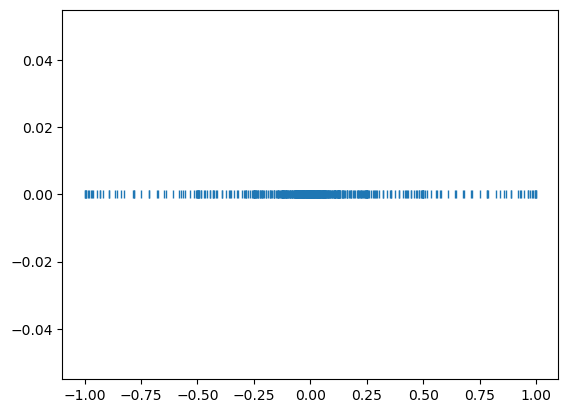

In [93]:
# (c)
points = []

def f(x):
    points.append(x)
    return np.sqrt(abs(x))

print(integrate.quad(f, -1, 1)[0])
plt.plot(points, [0] * len(points), '|')

print(romberg(f, -1, 1)[-1])
composite(f, -1, 1, k=10, quad=trapezoid)

In [ ]:
# 8.4
# (a) True
def f(x):
    return np.sqrt(x ** 3)

integrate.quad(f, 0, 1)

(0.39999999999722957, 2.8641677931471616e-09)

In [ ]:
# (b) False
def f(x):
    return 1 / (1 + 10 * x ** 2)

integrate.quad(f, 0, 1)

(0.39987600505576887, 2.7338956922499114e-11)

In [ ]:
# (c) False
def f(x):
    return (np.exp(-9 * x ** 2) + np.exp(-1024 * (x - 1/4) ** 2)) / np.sqrt(np.pi)

integrate.quad(f, 0, 1)

(0.19791298491716694, 4.757901155783765e-10)

In [ ]:
# (d) False
def f(x):
    return 50 / np.pi / (2500 * x ** 2 + 1)

integrate.quad(f, 0, 10)

(0.4993633810764567, 6.976406124240529e-12)

In [ ]:
# (e) True
def f(x):
    return 1 / np.sqrt(abs(x))

integrate.quad(f, -9, 100)

(26.000000000005958, 1.496758272878651e-11)

In [ ]:
# (f) True
def f(x):
    return 25 * np.exp(-25 * x)

integrate.quad(f, 0, 10)

(1.0, 9.084355112229901e-10)

In [ ]:
# (g) True
integrate.quad(np.log, 0, 1)

(-0.9999999999999999, 1.1102230246251563e-15)

0.7000000000000001 357


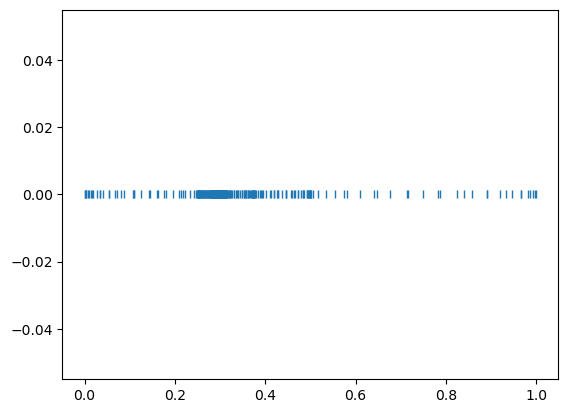

In [117]:
# 8.5
# (a)
points = []

def f(x):
    points.append(x)
    return 0 if x < .3 else 1


v, error, detail = integrate.quad(f, 0, 1, full_output=1)
print(v, detail['neval'])
plt.plot(points, [0] * len(points), '|')

0.7 42


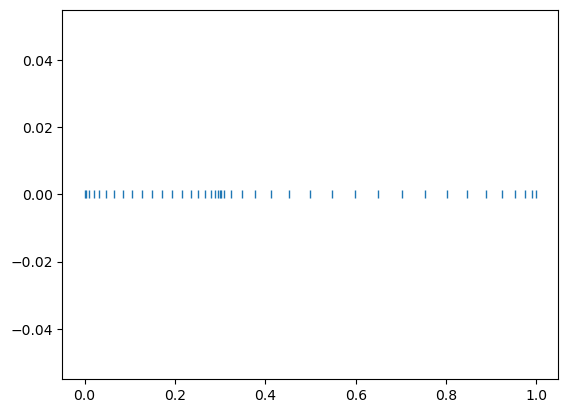

In [118]:
points.clear()

u, u_error, u_detail = integrate.quad(f, 0, .3, full_output=1)
v, v_error, v_detail = integrate.quad(f, .3, 1, full_output=1)

print(u + v, u_detail['neval'] + v_detail['neval'])
plt.plot(points, [0] * len(points), '|')

0.306852820409752 987


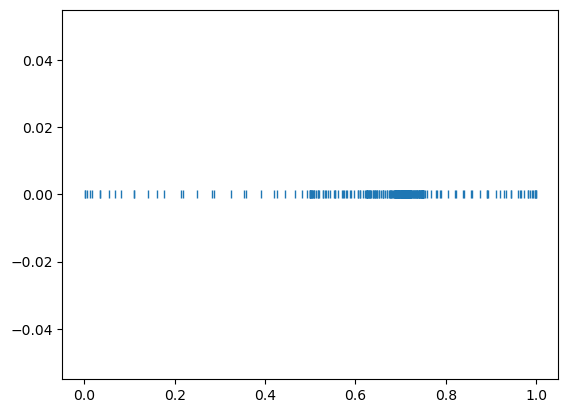

In [119]:
# (b)
points = []

def f(x):
    points.append(x)
    return 1 / (x + 2) if x < np.e - 2 else 0


v, error, detail = integrate.quad(f, 0, 1, full_output=1)
print(v, detail['neval'])
plt.plot(points, [0] * len(points), '|')

0.30685281944005466 42


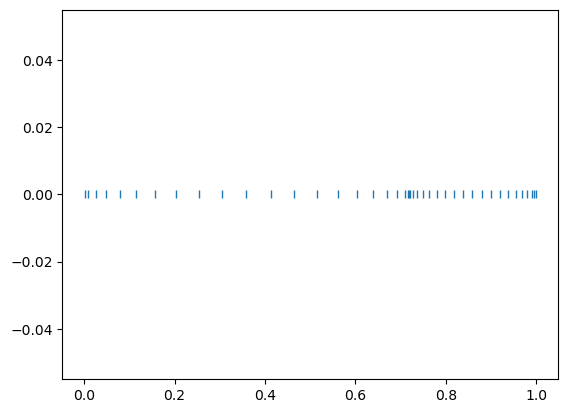

In [120]:
points.clear()

u, u_error, u_detail = integrate.quad(f, 0, np.e-2, full_output=1)
v, v_error, v_detail = integrate.quad(f, np.e-2, 1, full_output=1)

print(u + v, u_detail['neval'] + v_detail['neval'])
plt.plot(points, [0] * len(points), '|')